# Fisher-geometry pruning of symbolic models: a tutorial

This notebook walks through one complete pruning run on a **controlled case study**: a deliberately over-parametrised symbolic model fitted to noisy data generated by a simpler, known function. The goal is to recover a compact model ("emergent" model) without losing predictive accuracy.

**What the method does, in one paragraph.** At the current fit $\hat\theta$, the Fisher information $F = J^\top J/\sigma^2$ tells us which parameter changes the data cannot detect. From it we nominate *pruning moves*: scalar saturations $\theta_k \to 0,\,1,\,\pm\infty$ and signed identifications $\theta_i = \pm\theta_j$. Each candidate is refitted and scored by K-fold cross-validation; a move is **accepted only if the CV-MSE does not worsen by more than $\beta\cdot\mathrm{CV}_{\text{current}}$**, and BIC is used only to break ties between moves that CV cannot distinguish. Accepted moves are refitted with tight tolerances and the loop starts again.

**Outline**

1. Settings (everything you may want to change is in one cell)
2. Data and over-parametrised model
3. Initial fit, baseline CV and BIC
4. Fisher spectrum of the starting model
5. Pruning loop
6. Results
7. Figures

The pruning loop below is the same *full method* used by `ablation_case_studies.py`.

In [1]:
import os

import numpy as np
import sympy as sp
from sympy.core import evaluate

from emergentSR.emergent import (
    create_model,
    compute_lambdify_and_mle_estimates,
    kfold_cv_mse_for_sympy_model,
    bic_for_sympy_model,
    compute_eigenvecs_eigenvals_and_alignment,
    remove_and_recalibrate_sloppy_parameters,
    init_pruning_history,
    record_snapshot,
)
from emergentSR.plotting import latex_formula, plot_pruning_summary

## 1. Settings

All tunable quantities live in the next cell; the rest of the notebook only reads them.

* **Case study** – `MODEL` picks one of the models in `create_model`; `NOISE_LEVEL` selects the noise standard deviation from the two tables.
* **Fitting** – parameters are estimated by multi-start, ridge-continued least squares; random starts are drawn from $\mathcal N(\texttt{INIT\_LOC}, \texttt{INIT\_SCALE}^2)$ inside `DEF_BOUNDS`.
* **Fisher geometry** – an eigendirection of the Fisher matrix is *numerically unidentifiable* if $\ln\lambda <$ `LAMBDA_THRESHOLD`, or if it lies more than `LAMBDA_GAP_THRESHOLD` nats below the stiffest direction. A boundary is *within reach* if its squared Fisher distance is below `SNR_SQ` ($=4^2$, i.e. four standard errors).
* **Acceptance** – a move is admissible if $\Delta\mathrm{CV} \le$ `BETA` $\cdot\,\mathrm{CV}_{\text{current}}$. Moves whose $\Delta\mathrm{CV}$ are within `CV_EQUIV_K` CV standard errors of the best one are considered tied and ranked by $\Delta\mathrm{BIC}$.

The default values are those of `make_case_config` in `ablation_case_studies.py`.

In [2]:
# ---------------- case study ----------------
MODEL = "nested"          # 'nested', 'perturbative', 'multidimensional', 'near_alias_fourier',
                          # 'bessel', 'rational_gauge', 'competing_saturations', 'separable_2d',
                          # 'tanh_gauge', 'buried_transcendentals'
NOISE_LEVEL = "low"       # 'low' or 'high'
N_SAMPLES = 100
SEED = 42

# noise standard deviation per case study
HIGH_NOISE = dict(nested=1.5, perturbative=0.2, multidimensional=0.2, near_alias_fourier=0.2,
                  bessel=0.3, rational_gauge=0.2, competing_saturations=0.1, separable_2d=0.1,
                  tanh_gauge=0.15, buried_transcendentals=1.5)
LOW_NOISE = dict(nested=0.5, perturbative=0.05, multidimensional=0.05, near_alias_fourier=0.05,
                 bessel=0.05, rational_gauge=0.01, competing_saturations=0.01, separable_2d=0.01,
                 tanh_gauge=0.05, buried_transcendentals=0.2)

# ---------------- fitting ----------------
INIT_LOC, INIT_SCALE = 0.0, 0.1      # random multi-start distribution
DEF_BOUNDS = [(-100, 100)]           # one (low, high) pair shared by all parameters

# ---------------- Fisher geometry ----------------
LAMBDA_THRESHOLD = -10               # absolute floor on ln(lambda)
LAMBDA_GAP_THRESHOLD = 25.0          # relative gap (nats) below the stiffest direction
SNR_SQ = 16                          # Fisher-distance^2 threshold for "boundary within reach"

# ---------------- acceptance ----------------
CRITERION, SECOND_CRIT = "CV", "BIC" # CV decides, BIC breaks ties
BETA = 0.1                           # admissible CV worsening: BETA * current CV-MSE
CV_EQUIV_K = 2                       # tie band: CV_EQUIV_K * (CV standard error)
CANCEL_REMOVABLE = False             # opt-in: retry saturations that create a removable 0/0

# ---------------- pruning loop ----------------
PRUNING_MODES = ["unidentifiability", "zero_compatibility",
                 "infinity_compatibility", "signed_identifiability"]

# ---------------- output ----------------
VERBOSE = False                      # True prints every candidate, table and decision
SAVE_FIG = False
FIG_DIR = "./plots"

sigma_true = (LOW_NOISE if NOISE_LEVEL == "low" else HIGH_NOISE)[MODEL]

## 2. Data and over-parametrised model

`create_model` returns the inputs `x` (one array per variable), noisy targets `y`, the over-parametrised symbolic model to prune, the symbols, and the data-generating function `f_true` (with its noiseless values `y_true`).

In [3]:
np.random.seed(SEED)
x, y, model_sym, xs, params, f_true, y_true = create_model(MODEL, N_SAMPLES, sigma_true)

print(f"case study      : {MODEL}  (noise sd = {sigma_true}, n = {N_SAMPLES})")
print(f"true function   : {f_true}")
print(f"starting model  : {model_sym}")
print(f"parameters ({len(params)}) : {params}")

case study      : nested  (noise sd = 0.5, n = 100)
true function   : 0.7*x1**2 + 2*sin(1.5*x1)
starting model  : theta0*sin(theta1*x1) + theta2*x1**2 + theta3*x1**3 + theta4/(1 + exp(-theta5*x1)) + exp(theta6*x1 + theta7)
parameters (8) : [theta0, theta1, theta2, theta3, theta4, theta5, theta6, theta7]


## 3. Initial fit, baseline CV and BIC

The starting model is fitted once. Its K-fold CV-MSE and BIC are the baselines every later move is compared against; both are updated after each accepted move.

In [4]:
theta_mle, sigma_noise, model_func, jac_funcs = compute_lambdify_and_mle_estimates(
    model_sym, params, xs, x, y, DEF_BOUNDS, INIT_LOC, INIT_SCALE)

cv_start, cv_se_start = kfold_cv_mse_for_sympy_model(
    model_sym=model_sym, params=params, xs=xs, x=x, y=y,
    def_bounds=DEF_BOUNDS, init_loc=INIT_LOC, init_scale=INIT_SCALE,
    guess_init=list(theta_mle), return_se=True, verbose=VERBOSE)
bic_start = bic_for_sympy_model(params, model_func, theta_mle, x, y, beta=1)

start_pred = model_func(*(tuple(theta_mle) + tuple(x)))   # kept for the final figure

print("MLE parameters:")
for p, v in zip(params, theta_mle):
    print(f"  {str(p):>8s} = {v: .6g}")
print(f"\nresidual sd = {sigma_noise:.4g}   CV-MSE = {cv_start:.4g} (se {cv_se_start:.2g})   BIC = {bic_start:.2f}")

KeyboardInterrupt: 

## 4. Fisher spectrum of the starting model

One row per parameter $\theta_k$, associated with the eigendirection on which it loads most strongly:

| column | meaning |
|---|---|
| `ln(lambda)` | log-eigenvalue of that direction (small = sloppy) |
| `param_magnitude` | $|\hat\theta_k|$ |
| `zero`, `one`, `+inf`, `-inf` | squared Fisher distance from $\hat\theta$ to $\theta_k = 0,\,1,\,\pm\infty$ (infinities through $\phi_k = \arctan\theta_k$); a value below `SNR_SQ` means the boundary is statistically within reach |

The same table is recomputed after every accepted move and stored in the pruning *history*, together with the model and the CV/BIC values.

In [5]:
df = compute_eigenvecs_eigenvals_and_alignment(params, jac_funcs, theta_mle, x, y,
                                               sigma_noise, model_func).sort_values(by="ln(lambda)")

history = init_pruning_history()
record_snapshot(history, stage="init", action="start", model_sym=model_sym, params=params,
                theta_mle=theta_mle, sigma_noise=sigma_noise, df=df, x=x, model_func=model_func,
                criterion=CRITERION, criterion_value=cv_start,
                second_crit=SECOND_CRIT, second_crit_value=bic_start)

df[["main_param", "ln(lambda)", "param_magnitude", "zero", "one", "+inf", "-inf"]].round(3)

,main_param,ln(lambda),param_magnitude,zero,one,+inf,-inf
0,theta4,-9.565,3.318,0.097,0.164,10.319,0.109
1,theta5,-4.979,2.782,0.330,0.136,0.388,25.495
2,theta0,-2.082,1.916,6.296,1.439,8.659,264.900
3,theta2,-0.979,0.356,2.362,7.753,35.796,86.671
4,theta1,3.534,1.553,203.364,25.808,321.176,6482.198
5,theta7,4.262,0.726,0.082,0.012,0.321,1.743
6,theta3,10.155,0.113,0.044,4.294,10.076,7.568
7,theta6,10.155,0.506,8.246,7.860,61.743,211.284


## 5. Pruning loop

A **sweep** runs the four modes in order; each mode is iterated until none of its candidates is accepted:

1. `unidentifiability` – parameters representing numerically unidentifiable directions; all boundaries $0, 1, \pm\infty$ and plausible signed identifications are tried.
2. `zero_compatibility` – identifiable parameters with $\theta_k = 0$ within reach; try $\theta_k \to 0$.
3. `infinity_compatibility` – identifiable parameters with their sign-consistent infinity within reach; try $\theta_k \to \pm\infty$.
4. `signed_identifiability` – identifiable pairs with $|\theta_i| \approx |\theta_j|$ and $\theta_i = \pm\theta_j$ within reach.

Sweeps are repeated until a whole sweep removes nothing. Every accepted move is appended to `history`.

In [6]:
state = dict(model_sym=model_sym, params=list(params), model_func=model_func,
             jac_funcs=jac_funcs, theta=np.asarray(theta_mle, dtype=float),
             sigma=sigma_noise, df=df, cv=cv_start, bic=bic_start)


def _update(state, out):
    keys = ("model_sym", "params", "model_func", "theta", "sigma",
            "jac_funcs", "df", "cv", "bic")
    state.update(dict(zip(keys, out[:9])))
    return bool(out[9])                      # True if something was removed


def run_mode(state, mode):
    out = remove_and_recalibrate_sloppy_parameters(
        state["model_sym"], state["params"], state["model_func"], state["jac_funcs"], state["theta"],
        xs, x, y, state["sigma"], state["df"], DEF_BOUNDS, INIT_LOC, INIT_SCALE, BETA,
        CRITERION, state["cv"], SECOND_CRIT, state["bic"], None,
        snr_sq=SNR_SQ, cv_equiv_k=CV_EQUIV_K,
        lambda_threshold=LAMBDA_THRESHOLD, lambda_gap_threshold=LAMBDA_GAP_THRESHOLD,
        cancel_removable=CANCEL_REMOVABLE, pruning_mode=mode,
        verbose=VERBOSE, plot=False, history=history)
    return _update(state, out)


sweep = 0
while True:
    sweep += 1
    n_before = len(history)
    removed = False
    for mode in PRUNING_MODES:
        removed |= run_mode(state, mode)

    print(f"sweep {sweep}: {len(history) - n_before} move(s) accepted, "
          f"{len(state['params'])} parameters left")
    for snap in history[n_before:]:
        print(f"    [{snap['pruning_mode']}] {snap['removed_param']} -> {snap['boundary']}"
              f"   CV = {snap['criterion_value']:.4g}")
    if not removed:
        break

sweep 1: 3 move(s) accepted, 4 parameters left
    [zero_compatibility] theta4 -> zero   CV = 0.2211
    [zero_compatibility] theta6 -> zero   CV = 0.2079
    [zero_compatibility] theta3 -> zero   CV = 0.2062


sweep 2: 1 move(s) accepted, 3 parameters left
    [unidentifiability] theta7 -> -inf   CV = 0.2055
sweep 3: 0 move(s) accepted, 3 parameters left


## 6. Results

The pruned model is compared with the starting model and with the truth. $\Delta\mathrm{CV}$ should be within the admissible band ($\beta\cdot\mathrm{CV}$ per move), while the number of parameters and the expression size drop.

In [7]:
final_pred = state["model_func"](*(tuple(state["theta"]) + tuple(x)))
final_pred = np.broadcast_to(np.asarray(final_pred, dtype=float), np.shape(y))

# structural view: replace every parameter by a generic constant C
C = sp.Symbol("C", real=True)
with evaluate(False):
    structure = state["model_sym"].subs({p: C for p in state["model_sym"].free_symbols - set(xs)})

def mse(a, b):
    return float(np.mean((np.asarray(a) - np.asarray(b)) ** 2))

print(f"true function   : {f_true}")
print(f"starting model  : {model_sym}")
print(f"pruned model    : {state['model_sym']}")
print(f"structure       : {structure}")
print("\nfitted parameters:")
for p, v in zip(state["params"], state["theta"]):
    print(f"  {str(p):>8s} = {v: .6g}")

print(f"\n{'':18s}{'start':>12s}{'pruned':>12s}")
print(f"{'# parameters':18s}{len(params):>12d}{len(state['params']):>12d}")
print(f"{'CV-MSE':18s}{cv_start:>12.4g}{state['cv']:>12.4g}")
print(f"{'BIC':18s}{bic_start:>12.2f}{state['bic']:>12.2f}")
print(f"{'MSE vs truth':18s}{mse(start_pred, y_true):>12.4g}{mse(final_pred, y_true):>12.4g}")

true function   : 0.7*x1**2 + 2*sin(1.5*x1)
starting model  : theta0*sin(theta1*x1) + theta2*x1**2 + theta3*x1**3 + theta4/(1 + exp(-theta5*x1)) + exp(theta6*x1 + theta7)
pruned model    : theta0*sin(theta1*x1) + theta2*x1**2
structure       : C*x1**2 + C*sin(C*x1)

fitted parameters:
    theta0 = -1.87637
    theta1 = -1.51765
    theta2 =  0.69362

                         start      pruned
# parameters                 8           3
CV-MSE                  0.2248      0.2055
BIC                     154.40      135.39
MSE vs truth           0.01715    0.009226


## 7. Figures

* **Model fit** – data, starting model and pruned model (against the first input variable), with the pruned formula; parameter indices refer to the starting model.
* **Fisher spectrum** – $\ln\lambda_i$ at every step of the history; each curve is labelled by the move that produced it. Sloppy directions disappear as the model is pruned.
* **Selection trajectory** – CV-MSE (left axis) and BIC relative to the start (right axis) after each accepted move.

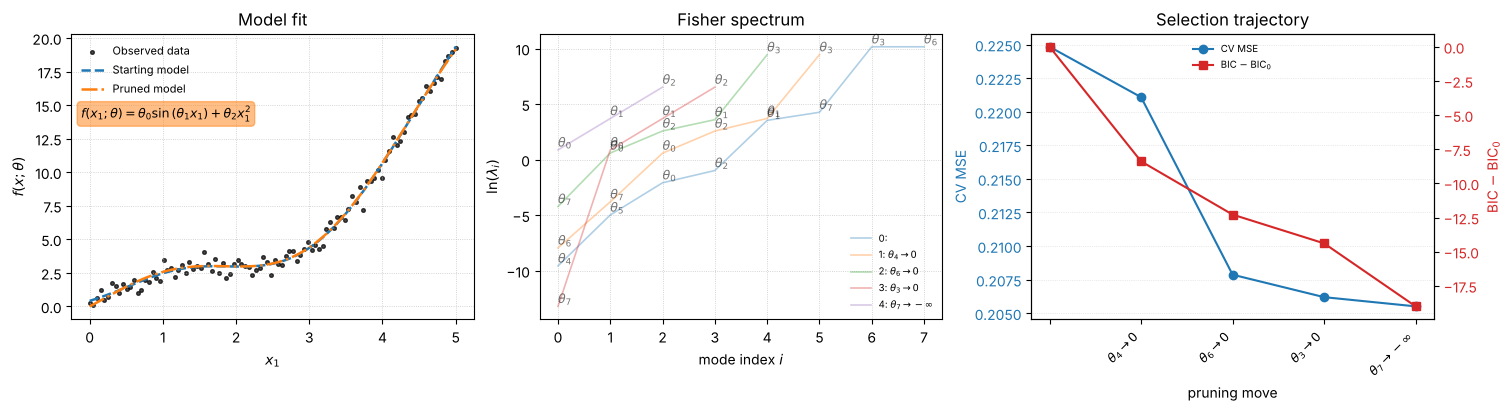

In [8]:
formula = latex_formula(state["model_sym"], params, xs)

savepath = None
if SAVE_FIG:
    os.makedirs(FIG_DIR, exist_ok=True)
    savepath = os.path.join(FIG_DIR, f"{MODEL}_summary_{CRITERION}_{SECOND_CRIT}_{NOISE_LEVEL}.pdf")

plot_pruning_summary(x, y, start_pred, final_pred, history, formula=formula, savepath=savepath);

## Next steps

* Change `MODEL` / `NOISE_LEVEL` in the settings cell and re-run the notebook to explore the other case studies.
* Set `VERBOSE = True` to see every candidate move, its $\Delta\mathrm{CV}$ / $\Delta\mathrm{BIC}$ and the acceptance decision.
* `ablation_case_studies.py` runs all case studies over 30 seeds and compares the full method with four baselines; `operon_ablation.py` does the same on real Operon populations.